# COGS 108 - Final Project (change this to your project's title)

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [X] YES - make available
* [  ] NO - keep private

# Names

- Maria Evangelista
- Monica Dai
- Maya Ruddick
- Diego Inostroza

# Abstract

This project aims to create a predictive model for used car pricing in the United States that takes into consideration the relative importance of different factors such as make, model, mileage, and accident history. We compared a Random Forest Regressor and, most successfully, an XGBoost Regressor to our baseline model to find which factors most heavily influenced selling price.

Across all models, we found that the top three most important factors influencing the selling price of used cars were mileage, year, and drive train (AWD/4WD). Our XGBoost Regressor performs well at predicting these selling prices, with an R-squared value of 0.8049. 

# Research Question

-  For used cars in America, which factors (e.g. model, maker, fuel type, accident history) about a used car are most important in predicting its selling price?



## Background and Prior Work


For our project, we have decided to create a machine learning program that will predict the future prices of used cars, using past car sales data trends. Due to the immense popularity of used cars due to rising inflation and their affordability compared to new vehicles, we believe that this project will have many real world applications. This project aims to take the multiple factors that contribute to the pricing of used vehicles into consideration to generate a predictive model. Factors such as model, mileage, years used, and engine all contribute to the varied pricing of used cars, with the most important factor being the manufacturer of the car <a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1).


Zhengwei Sun asked a similar question in his publication, as he used a multiple linear regression model to analyze key factors affecting second-hand car prices. From his research, he concluded that the mileage and model year were significantly related to the price of a used car <a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1). Abdulla Alshared approached the same question using three different regressors, finding that the Random Forest Regressor provided the most accurate predictions <a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2).  Marcus Collard also found that when using regressors, the Random Forest Regressor proves to be the most accurate by an R-squared test, as well as that Linear Regression, Ridge Regression, and Lasso Regression are all likely to predict the price to be lower than it actually is <a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3).

Our project will be different for multiple reasons. First of all, the COVID pandemic has led to a significant impact on our society. Because of this, many predictive models are outdated and important factors are likely to have changed as a result of this. Also, we plan to use the packages, “SHAP” and “scikit-learn”. These packages will allow us to experiment with several different models and convert them into more explainable outputs that allow us to see the importance of each factor.
1. <a name="cite_note-1"></a> [^](#cite_ref-1) Sun, Zhengwei. “Research on Factors Affecting Second-Hand Car Market Prices.” Researchgate, May 2024, www.researchgate.net/publication/382400299_Research_on_factors_affecting_second-hand_car_market_prices. 
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Collard, Marcus. “Price Prediction for Used Cars.” Diva-Portal, spring 2022, www.diva-portal.org/smash/get/diva2:1674070/FULLTEXT01.pdf 
3. <a name="cite_note-3"></a> [^](#cite_ref-3) AlShared, Abdulla. “Used Cars Price Prediction and Valuation Using Data Mining ...” RIT Digital Institutional Repository, Dec. 2021, repository.rit.edu/cgi/viewcontent.cgi?article=12220&context=theses 


# Hypothesis



We predict that the accident history will have the most significant impact on the prediction of the price of used cars. Because of the cost of repairs and how much value is tied to the condition of a car, we believe that this will be the strongest correlator of how much a car will cost.

# Data

## Data overview

- Primary Dataset
  - Dataset Name: Used Cars Dataset
  - Link to the dataset: https://www.kaggle.com/datasets/andreinovikov/used-cars-dataset
  - Number of observations: 762,091
  - Number of variables: 20

- General Info:
  - Car name/model
  - Manufacturer/brand 
  - Year 
  - Mileage
  - Exterior Color
  - Interior Color
  - Driver Rating: car rating given by drivers
  - Number of Driver Reviews: number of reviews left by drivers
- Pricing:
  - Price (target variable)
  - Price Drop: reduction from original listing price of the car
- Engine & performance:
  - Engine type
  - Drivetrain
  - Fuel type: what kind of fuel the car takes (petrol, diesel, hybrid, electric)
  - Transmission: automatic or manual
  - Miles per Gallon of Fuel
- Condition & usage:
  - Mileage: total distance traveled
  - Accident history: clean or salvaged titles
  - Number of previous owners
  - Registration status of vehicle
  - Personal Use: whether the car was used only for personal purposes
- Seller and Driver ratings:
  - Seller name
  - Seller rating

We plan to utilize this dataset by preprocessing and cleaning the data to ensure accuracy. This mostly means handling inconsistencies within the categorical variables and potentially collapsing them into fewer categories. Once we prep the data, we will conduct EDA to identify trends in used car pricing by looking and analyzing correlations between different features. Through visualizations, we will compare price distributions, highlight outliers, and make note of notable market shifts. Then we will process the data more to handle missing values in key columns like fuel_type, mileage, etc. We will also convert categorical variables like fuel type and transmission into numerical values for modeling, then experiment with various regressors. Ultimately, our goal is to interpret these findings to understand which car attributes most define used car pricing and how external factors influence resale prices. By following our planned approach, we aim to provide data-driven insights into used car pricing trends.

## Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.animation as animation
from IPython.display import Image, display

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import shap
import xgboost

## Used Cars Dataset

In [2]:
used_cars = pd.read_csv('data/used_cars.csv')
used_cars.head()

,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,Parchment,0.0,0.0,0.0,Iconic Coach,NaN,4.4,12.0,300.0,13988.0
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,Kars Today,NaN,4.4,12.0,NaN,17995.0
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,Apple Tree Acura,NaN,4.4,12.0,675.0,14958.0
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0


In [3]:
used_cars.shape

(762091, 20)

In [4]:
used_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762091 entries, 0 to 762090
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   manufacturer         762091 non-null  object 
 1   model                762091 non-null  object 
 2   year                 762091 non-null  int64  
 3   mileage              761585 non-null  float64
 4   engine               747041 non-null  object 
 5   transmission         752187 non-null  object 
 6   drivetrain           740529 non-null  object 
 7   fuel_type            739164 non-null  object 
 8   mpg                  620020 non-null  object 
 9   exterior_color       753232 non-null  object 
 10  interior_color       705116 non-null  object 
 11  accidents_or_damage  737879 non-null  float64
 12  one_owner            730608 non-null  float64
 13  personal_use_only    737239 non-null  float64
 14  seller_name          753498 non-null  object 
 15  seller_rating    

In [5]:
used_cars.isna().sum()

manufacturer                0
model                       0
year                        0
mileage                   506
engine                  15050
transmission             9904
drivetrain              21562
fuel_type               22927
mpg                    142071
exterior_color           8859
interior_color          56975
accidents_or_damage     24212
one_owner               31483
personal_use_only       24852
seller_name              8593
seller_rating          213973
driver_rating           31632
driver_reviews_num          0
price_drop             351979
price                       0
dtype: int64

Ideas for Handling Missing Values (future work)

- **mileage**: mean imputation on year

- **transmission**, **drivetrain**, **fuel_type**: try to impute based on other observations of same model/year

Drop Columns:

- **engine**: very dense and inconsistent data inputted, difficult to extract most useful information and OHE would result in too many variables. May not provide such useful information towards predicting prices either, so we decided to drop.

- **mpg** (miles per gallon): many nulls and only applicable to non-electric vehicles. May try to train with using a RandomForestRegressor, but otherwise may not provide the most valuable information, and realistically canont impute for EVs.

- **exterior_color**, **interior_color**: many nulls and cannot really impute (though we could try conditional random imputation). Also with model/year constant, color likely doesn't make much more difference in price.

- **seller_name**: we don't believe this is a very primary variable and that it would provide much useful insight.

- **seller_rating**, **driver_rating**, **driver_reviews_num**: many nulls for seller and driver rating. Could try conditional mean imputation but not all used cars come with this information, so not very valuable towards our goal of identifying car attributes that are important towards predicting used car price.

- **price_drop**: indicates price drops since initial listing price, but many nulls and not very applicable towards our problem either.

In [6]:
used_cars['engine'].value_counts()

2.0L I4 16V GDI DOHC Turbo             75545
3.6L V6 24V MPFI DOHC                  35437
3.6L V6 24V GDI DOHC                   27020
2.0L I4 16V MPFI DOHC                  19534
1.5L I4 16V GDI DOHC Turbo             18173
                                       ...  
L                                          1
450 CID V8                                 1
302CI V8                                   1
5.8L 8 Cylinder                            1
2.5L 5-cylinder turbocharged engine        1
Name: engine, Length: 6903, dtype: int64

In [7]:
to_drop = ['engine', 'mpg', 'exterior_color', 'interior_color', 'seller_name', 'seller_rating', 'driver_rating', 'driver_reviews_num', 'price_drop']
used_cars = used_cars.drop(columns=to_drop)
used_cars

,manufacturer,model,year,mileage,transmission,drivetrain,fuel_type,accidents_or_damage,one_owner,personal_use_only,price
0,Acura,ILX Hybrid 1.5L,2013,92945.0,Automatic,Front-wheel Drive,Gasoline,0.0,0.0,0.0,13988.0
1,Acura,ILX Hybrid 1.5L,2013,47645.0,Automatic CVT,Front-wheel Drive,Hybrid,1.0,1.0,1.0,17995.0
2,Acura,ILX Hybrid 1.5L,2013,53422.0,Automatic CVT,Front-wheel Drive,Hybrid,0.0,1.0,1.0,17000.0
3,Acura,ILX Hybrid 1.5L,2013,117598.0,Automatic CVT,Front-wheel Drive,Hybrid,0.0,1.0,1.0,14958.0
4,Acura,ILX Hybrid 1.5L,2013,114865.0,Automatic CVT,Front-wheel Drive,Hybrid,1.0,0.0,1.0,14498.0
...,...,...,...,...,...,...,...,...,...,...,...
762086,Volvo,S60 B5 Momentum,2022,22877.0,8-Speed Automatic,All-wheel Drive,Gasoline,0.0,1.0,0.0,34798.0
762087,Volvo,S60 T5,2012,72900.0,A/T,Front-wheel Drive,Gasoline,NaN,NaN,NaN,12500.0
762088,Volvo,S60 T5,2014,92000.0,6-Speed Automatic,Front-wheel Drive,Gasoline,0.0,0.0,1.0,12299.0
762089,Volvo,S60 T5 Platinum,2013,132000.0,6-Speed Automatic,All-wheel Drive,Gasoline,1.0,0.0,0.0,8995.0


### manufacturer

In [8]:
manufacturers = used_cars['manufacturer'].value_counts()
print(manufacturers.shape)
manufacturers.head(10)

(30,)


Ford             79526
Toyota           59535
Chevrolet        56043
Nissan           48529
Jeep             41665
Mercedes-Benz    40824
Honda            37612
BMW              37570
Kia              35063
GMC              29563
Name: manufacturer, dtype: int64

### model

In [9]:
models = used_cars['model'].value_counts()
print(models.shape)
models.head(10)

(12187,)


Fusion SE              3172
Sportage LX            2873
Corolla LE             2836
GLC 300 Base 4MATIC    2718
Sentra SV              2652
Optima LX              2650
Explorer XLT           2542
Rogue SV               2526
Tundra SR5             2471
Sorento LX             2461
Name: model, dtype: int64

### year

In [ ]:
used_cars['year'].describe()

count    762091.000000
mean       2017.791398
std           5.110532
min        1915.000000
25%        2016.000000
50%        2019.000000
75%        2021.000000
max        2024.000000
Name: year, dtype: float64

In [11]:
used_cars[used_cars['year'] == 1915]

,manufacturer,model,year,mileage,transmission,drivetrain,fuel_type,accidents_or_damage,one_owner,personal_use_only,price
269785,Ford,Model T Touring,1915,0.0,2 Speed Ruckstell Rear Axle Manual,NaN,NaN,0.0,NaN,1.0,33000.0
269791,Ford,Model T,1915,0.0,2 Speed Manual,NaN,NaN,0.0,NaN,1.0,26000.0


(array([1.0000e+01, 8.7000e+01, 5.9000e+01, 3.5000e+02, 9.2100e+02,
        8.6800e+02, 1.1500e+03, 5.6930e+03, 8.3803e+04, 6.6915e+05]),
 array([1915. , 1925.9, 1936.8, 1947.7, 1958.6, 1969.5, 1980.4, 1991.3,
        2002.2, 2013.1, 2024. ]),
 <BarContainer object of 10 artists>)

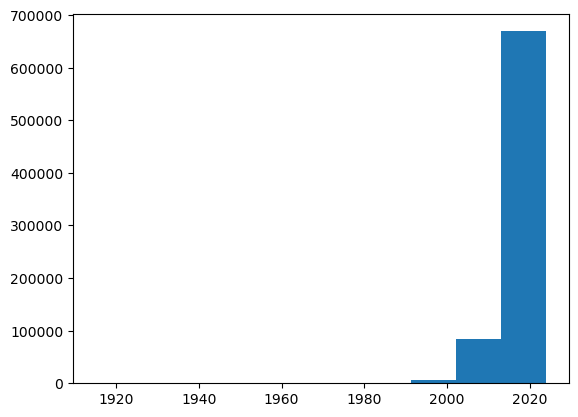

In [12]:
plt.hist(used_cars['year'])

### mileage

In [13]:
used_cars['mileage'].describe()

count    7.615850e+05
mean     5.578169e+04
std      4.355788e+04
min      0.000000e+00
25%      2.328700e+04
50%      4.559600e+04
75%      7.836500e+04
max      1.119067e+06
Name: mileage, dtype: float64

In [14]:
# not very new but mileage = 0, need to investigate further in eda
used_cars[used_cars['mileage'] == 0].head()

,manufacturer,model,year,mileage,transmission,drivetrain,fuel_type,accidents_or_damage,one_owner,personal_use_only,price
22,Acura,NSX Base,2017,0.0,9-Speed Automatic with Auto-Shift,All-wheel Drive,Hybrid,0.0,0.0,0.0,177084.0
96,Acura,ZDX Base,2012,0.0,6-Speed Automatic,All-wheel Drive,Gasoline,0.0,0.0,1.0,22490.0
269,Acura,ILX Base,2020,0.0,8-Speed Automatic with Auto-Shift,Front-wheel Drive,Gasoline,0.0,1.0,1.0,23995.0
299,Acura,ILX Base,2020,0.0,8-Speed Automatic with Auto-Shift,Front-wheel Drive,Gasoline,0.0,1.0,1.0,23995.0
516,Acura,ILX Premium Package,2020,0.0,8-Speed Automatic with Auto-Shift,Front-wheel Drive,Gasoline,0.0,1.0,1.0,24995.0


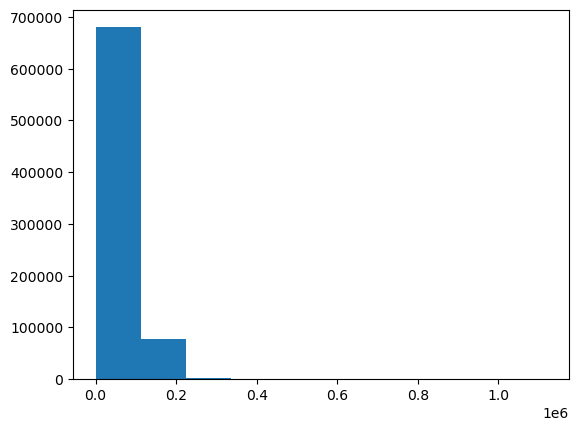

In [15]:
plt.hist(used_cars['mileage'])
plt.show()

### transmission

In [16]:
used_cars['transmission'].value_counts()

6-Speed Automatic              148597
8-Speed Automatic              139572
Automatic CVT                  108624
Automatic                       97123
9-Speed Automatic               61189
                                ...  
Rebuilt 3 Speed Auto                1
4-tomatic 2 Speed Automatic         1
Top Load 4-Speed Manual             1
Top Loader 4 Speed Manual           1
9Speed AT                           1
Name: transmission, Length: 1313, dtype: int64

In [17]:
# classifying transmission into two main categories: automatic or manual
auto = ['auto', 'at', 'a/t', 'continuously variabl', 'cvt', 'dual shift', 'ivt', 'intelligent variable', 'shiftronic', 'controlled variable', 'single speed', 'dual clutch', 'double clutch', 'pdk', '1 speed', 'dct', 'tiptronic', 'select', 'touchshift', 'evt']
manual = ['manual', 'm/t', '5 speed']

new_trans = used_cars['transmission'].str.lower().str.replace('-', ' ').apply(lambda x: np.nan if type(x) != str else 'automatic' if any([a in x for a in auto]) else 'manual' if any([m in x for m in manual]) else np.nan)
transmission = pd.concat([new_trans, used_cars['transmission']], axis=1)
transmission.columns = ['new_trans', 'transmission']
used_cars['transmission'] = transmission['new_trans']

# many of the remaining are unknown or unable to determine whether automatic or manual
transmission[(~transmission['transmission'].isna()) & (transmission['new_trans'].isna())]['transmission'].value_counts().head(10)

Variable                 2388
6-Speed                   893
8-Speed                   420
A                         294
7-Speed                   192
NOT SPECIFIED              94
AWD                        77
Not Specified              76
10-SPEED TRANSMISSION      75
OTHER                      50
Name: transmission, dtype: int64

In [18]:
used_cars['transmission'].value_counts(dropna=False)

automatic    723278
manual        24120
NaN           14693
Name: transmission, dtype: int64

### fuel_type

In [19]:
used_cars['fuel_type'].value_counts().head(10)

Gasoline                         644644
Hybrid                            29141
Diesel                            27967
E85 Flex Fuel                     18772
Electric                          16192
B                                  1442
Flexible Fuel                       493
Plug-In Hybrid                      118
Gasoline Fuel                        80
Gasoline/Mild Electric Hybrid        70
Name: fuel_type, dtype: int64

In [20]:
# collapsing fuel_type into four main categories: gasoline, diesel, electric or hybrid
hybrid = ['hybrid', 'plug-in', 'phev']
gas = ['gasoline', 'gas', 'unleaded', 'premium', 'g', 'e85', 'flexible fuel', 'flex fuel']
diesel = ['diesel']
ev = ['electric']

new_fuel = used_cars['fuel_type'].str.lower().apply(lambda x: np.nan if type(x) != str 
                                                                          else 'hybrid' if any([h in x for h in hybrid]) 
                                                                          else 'gas' if any([g in x for g in gas])
                                                                          else 'diesel' if any([d in x for d in diesel])
                                                                          else 'electric' if any([e in x for e in ev])
                                                                          else np.nan
                                                                        )
fuel = pd.concat([new_fuel, used_cars['fuel_type']], axis=1)
fuel.columns = ['new_fuel', 'fuel_type']
used_cars['fuel_type'] = fuel['new_fuel']

# can try to impute, but need to ensure accurate imputations
fuel[(~fuel['fuel_type'].isna()) & (fuel['new_fuel'].isna())]['fuel_type'].value_counts()

B              1442
Unspecified      26
Other             3
Unknown           1
Bi-Fuel           1
Automatic         1
Name: fuel_type, dtype: int64

In [21]:
used_cars['fuel_type'].value_counts(dropna=False)

gas         664183
hybrid       29339
diesel       27974
NaN          24401
electric     16194
Name: fuel_type, dtype: int64

### drivetrain

In [22]:
used_cars['drivetrain'].value_counts().head(10)

Front-wheel Drive    241432
All-wheel Drive      230219
Four-wheel Drive     157082
Rear-wheel Drive      97437
FWD                    6450
AWD                    3586
4WD                    1923
RWD                    1758
All-Wheel Drive         120
Unknown                 105
Name: drivetrain, dtype: int64

In [23]:
# collapsing drivetrain into three main categories: FWD, RWD, AWD
fwd = ['front wheel', 'fwd']
rwd = ['rear wheel', 'rwd', '4x2']
awd_4wd = ['all wheel', 'awd', '4wd', 'four wheel', '4x4']

new_drivetrain = used_cars['drivetrain'].str.lower().str.replace('-', ' ').apply(lambda x: np.nan if type(x) != str 
                                                                          else 'FWD' if any([f in x for f in fwd]) 
                                                                          else 'RWD' if any([r in x for r in rwd])
                                                                          else 'AWD/4WD' if any([a in x for a in awd_4wd])
                                                                          else np.nan
                                                                        )
drivetrain = pd.concat([new_drivetrain, used_cars['drivetrain']], axis=1)
drivetrain.columns = ['new_drivetrain', 'drivetrain']
used_cars['drivetrain'] = drivetrain['new_drivetrain']

# engine != drivetrain and cannot determine if 2WD is FWD or RWD; can try to impute, but need to ensure accurate imputations
drivetrain[(~drivetrain['drivetrain'].isna()) & (drivetrain['new_drivetrain'].isna())]['drivetrain'].value_counts()

Unknown                                             105
Engine: 2.4L GDI DOHC 16V I4 -inc: dual CVVT          5
Engine: Lambda II 3.8L GDI DOHC V6 w/Dual CVVT        1
Engine: 2.4L DOHC I4 GDI                              1
Engine: 1.6L DOHC I4 GDI Turbo                        1
Engine: 1.6L 4-Cyl. 16-Valve MPI                      1
Engine: 2.0L 4-Cylinder MPI 16V DOHC w/Dual CVVT      1
2WD                                                   1
Name: drivetrain, dtype: int64

In [24]:
used_cars['drivetrain'].value_counts(dropna=False)

AWD/4WD    393115
FWD        248047
RWD         99251
NaN         21678
Name: drivetrain, dtype: int64

### accidents_or_damage

In [25]:
used_cars['accidents_or_damage'].value_counts(dropna=False)

0.0    569188
1.0    168691
NaN     24212
Name: accidents_or_damage, dtype: int64

In [26]:
used_cars['one_owner'].value_counts(dropna=False)

1.0    410579
0.0    320029
NaN     31483
Name: one_owner, dtype: int64

In [27]:
used_cars['personal_use_only'].value_counts(dropna=False)

1.0    484522
0.0    252717
NaN     24852
Name: personal_use_only, dtype: int64

In [28]:
# weird min and max values, will have to examine further
used_cars['price'].describe()

count    7.620910e+05
mean     3.648898e+04
std      1.984183e+06
min      1.000000e+00
25%      1.958300e+04
50%      2.798900e+04
75%      3.948800e+04
max      1.000000e+09
Name: price, dtype: float64

In [29]:
used_cars.sort_values('price', ascending=False)

,manufacturer,model,year,mileage,transmission,drivetrain,fuel_type,accidents_or_damage,one_owner,personal_use_only,price
188113,Dodge,Durango Citadel,2018,113207.0,automatic,AWD/4WD,gas,0.0,1.0,1.0,1.000000e+09
108142,Chevrolet,Cobalt LT,2009,85185.0,automatic,FWD,gas,0.0,1.0,1.0,1.000000e+09
188260,Dodge,Durango Citadel,2018,113207.0,automatic,AWD/4WD,gas,0.0,1.0,1.0,1.000000e+09
224571,Ford,Utility Police Interceptor Base,2016,NaN,automatic,AWD/4WD,NaN,1.0,1.0,0.0,8.888889e+06
84358,Cadillac,DeVille 77 HOURS ON ENGINES,1963,76.0,automatic,NaN,NaN,1.0,NaN,1.0,4.999999e+06
...,...,...,...,...,...,...,...,...,...,...,...
584638,Nissan,Versa SV,2021,45288.0,automatic,FWD,gas,0.0,0.0,0.0,2.590000e+02
5658,Acura,TLX V6 A-Spec,2018,49603.0,automatic,FWD,gas,1.0,0.0,1.0,1.000000e+00
13850,Audi,A4 2.0T Premium,2014,98881.0,automatic,FWD,gas,NaN,NaN,NaN,1.000000e+00
735177,Volkswagen,Jetta,2007,133964.0,manual,FWD,gas,1.0,0.0,1.0,1.000000e+00


### Removing Outliers

While we have cleaner data, some of our data in categories like mileage and price are still abnormal and might skew our predictions.

array([[<AxesSubplot:title={'center':'price'}>]], dtype=object)

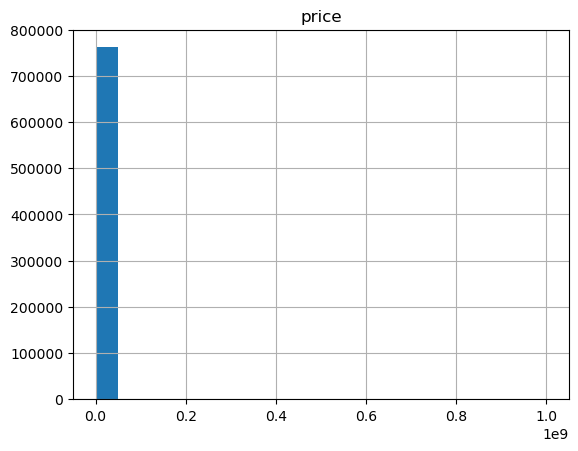

In [30]:
used_cars.get(['price']).hist(bins = 20)

To fix this, we have several options:
- **Using the Interquartile Range**: We can calculate the interquartile range of each cokumn (the difference between the third and first quartile), and create bounds by the equations "Q1 - (1.5 * IQR)" and "Q3 + (1.5 * IQR)". Any data outside these bounds are then removed.

- **Using Standard Deviations**: We first can calculate the mean and standard deviation of one of our colmns. Using these values, we can create boundaries by removing any values that are further than two standard deviations away from our mean.

- **Using Visuals**: By plotting and identifying extreme outliers. We can then remove any extreme values. However, because we are working with a large dataset, this is an impractical approach.


For our dataset, we will use the IQR approach, as the standard deviation may be affected by how our data is skewed. The Pandas library also has a convenient function, "pd.DataFrame.quantile()", which we can use.


In [31]:
def remove_outliers(data):
    
    #Calculate the quartiles
    Q_One = data.quantile(0.25)
    Q_Three = data.quantile(0.75)

    IQR = Q_Three - Q_One

    #Calculate the bounds
    Lower_Bound = Q_One - (IQR * 1.5)
    Upper_Bound = Q_Three + (IQR * 1.5)

    #Parse and filter the data, enter the new data into a new array that we can return. 
    #If they are outliers, mark them for deletion with a nan.
    New_Data = np.full(shape=len(data), fill_value=np.nan)
    for i, value in enumerate(data):
        if value > Lower_Bound and value < Upper_Bound:
            New_Data[i] = value
            

    return New_Data
    

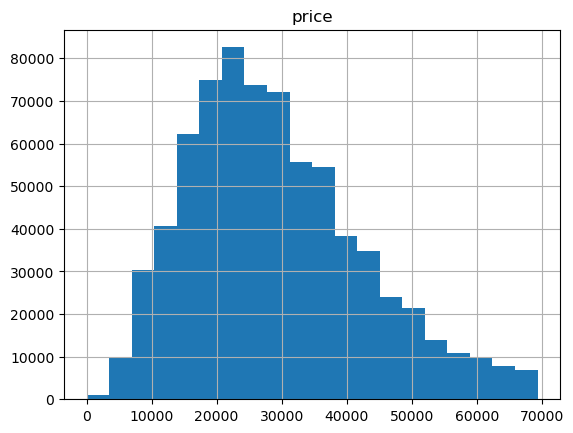

In [32]:
used_cars['price'] = remove_outliers(used_cars.get('price'))
#When we remake our price histogram, we can see that our data is now far more normally distributed.
used_cars.get(['price']).hist(bins = 20)
plt.show()

In [33]:
used_cars.sort_values('price').head()

,manufacturer,model,year,mileage,transmission,drivetrain,fuel_type,accidents_or_damage,one_owner,personal_use_only,price
5658,Acura,TLX V6 A-Spec,2018,49603.0,automatic,FWD,gas,1.0,0.0,1.0,1.0
13850,Audi,A4 2.0T Premium,2014,98881.0,automatic,FWD,gas,NaN,NaN,NaN,1.0
735177,Volkswagen,Jetta,2007,133964.0,manual,FWD,gas,1.0,0.0,1.0,1.0
660696,Subaru,Legacy 2.5i Limited,2019,31570.0,automatic,AWD/4WD,gas,NaN,NaN,NaN,1.0
584638,Nissan,Versa SV,2021,45288.0,automatic,FWD,gas,0.0,0.0,0.0,259.0


We also recognize that two rows in the dataframe have price = 1. This is abnormal, and will also be removed.

In [34]:
used_cars = used_cars[used_cars['price'] > 1]
used_cars.sort_values('price').head()

,manufacturer,model,year,mileage,transmission,drivetrain,fuel_type,accidents_or_damage,one_owner,personal_use_only,price
584638,Nissan,Versa SV,2021,45288.0,automatic,FWD,gas,0.0,0.0,0.0,259.0
195371,Ford,EcoSport Titanium,2019,44077.0,automatic,FWD,gas,1.0,0.0,0.0,289.0
599832,Nissan,Murano SV,2018,120524.0,NaN,AWD/4WD,gas,0.0,0.0,1.0,299.0
600748,Nissan,Murano SV,2018,120524.0,NaN,AWD/4WD,gas,0.0,0.0,1.0,299.0
66049,Buick,Enclave Premium,2017,115869.0,automatic,FWD,gas,1.0,0.0,1.0,299.0


We can now repeat this process for the mileage column of our dataset.


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


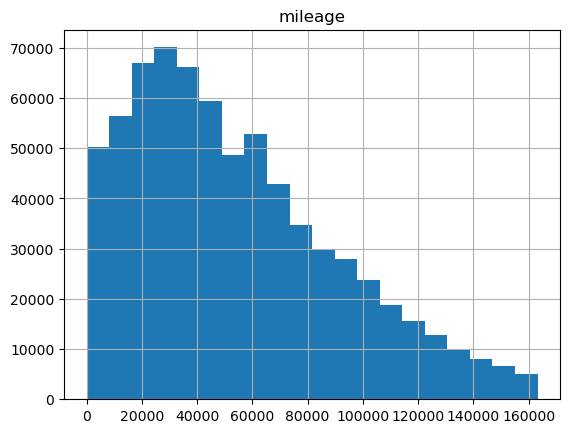

In [35]:
used_cars['mileage'] = remove_outliers(used_cars.get('mileage'))
used_cars.get(['mileage']).hist(bins = 20)
plt.show()

However, we still have null values after removing outliers. We remove rows with nulls rather than imputing, since we want to avoid introducing potential bias through imputation. Bias is probable even with conditional imputations, as car data can vary greatly even within the same year and model. The size of our dataset also provides for meaningful analysis despite dropping nulls.

In [36]:
used_cars = used_cars.dropna()
used_cars.shape

(647932, 11)

### Cleaned Dataset

In [37]:
used_cars.head()

,manufacturer,model,year,mileage,transmission,drivetrain,fuel_type,accidents_or_damage,one_owner,personal_use_only,price
0,Acura,ILX Hybrid 1.5L,2013,92945.0,automatic,FWD,gas,0.0,0.0,0.0,13988.0
1,Acura,ILX Hybrid 1.5L,2013,47645.0,automatic,FWD,hybrid,1.0,1.0,1.0,17995.0
2,Acura,ILX Hybrid 1.5L,2013,53422.0,automatic,FWD,hybrid,0.0,1.0,1.0,17000.0
3,Acura,ILX Hybrid 1.5L,2013,117598.0,automatic,FWD,hybrid,0.0,1.0,1.0,14958.0
4,Acura,ILX Hybrid 1.5L,2013,114865.0,automatic,FWD,hybrid,1.0,0.0,1.0,14498.0


In [38]:
used_cars.isna().sum()

manufacturer           0
model                  0
year                   0
mileage                0
transmission           0
drivetrain             0
fuel_type              0
accidents_or_damage    0
one_owner              0
personal_use_only      0
price                  0
dtype: int64

# Results

## Exploratory Data Analysis



### Visualizations

#### Distribution of Car Prices:

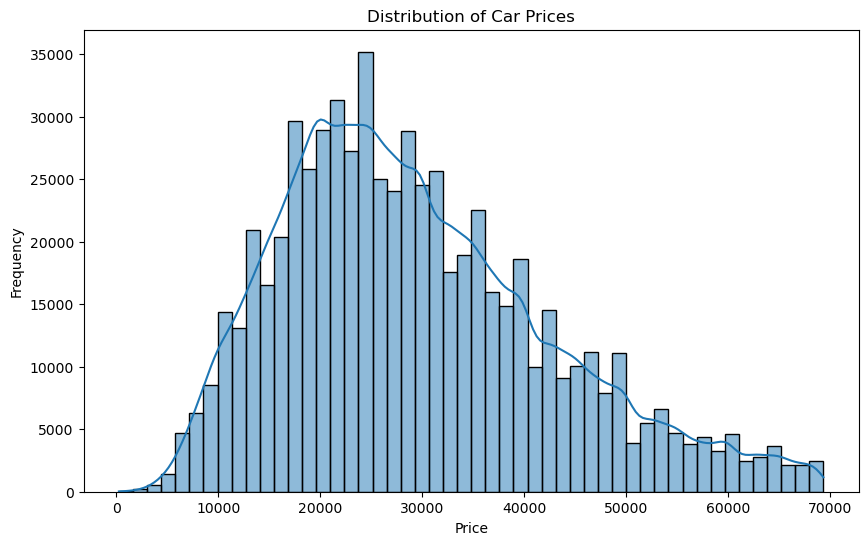

In [39]:
plt.figure(figsize=(10, 6)) 
sns.histplot(used_cars['price'], bins=50, kde=True) 
plt.title('Distribution of Car Prices') 
plt.xlabel('Price') 
plt.ylabel('Frequency') 
plt.show()

The histogram reveals that the majority of vehicles fall between the $10,000 to $40,000 range, with a peak concentration around $20,000 to $30,000. The distribution is slightly skewed to the right, indicating that while most cars are priced within a moderate range, a small number of high-end vehicles push the upper limit towards $70,000. The presence of a density curve suggests a near-normal distribution, with a long tail of luxury or collector cars extending beyond the average price range.

#### Distribution of Price vs Year:

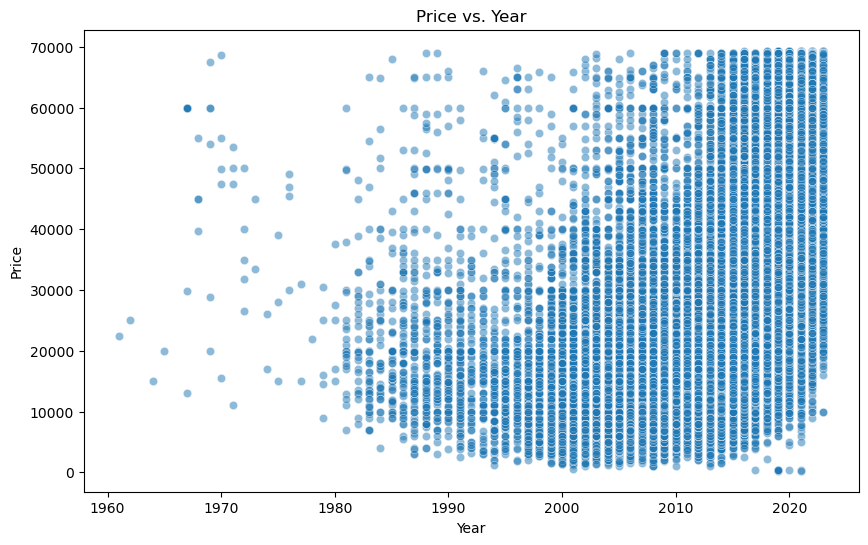

In [40]:
plt.figure(figsize=(10, 6)) 
sns.scatterplot(x='year', y='price', data=used_cars, alpha=0.5) 
plt.title('Price vs. Year')
plt.xlabel('Year') 
plt.ylabel('Price') 
plt.show()


While the scatterplot points are spread out, the scatterplot shows a generally positive trend associated with the year of the car. This shows that year is an important factor that is associated with the price of a car. However, because the cars within each year have a large range of prices, we can see that this also cannot be used alone to predict the price. In order to create a more accurate predictive model, other variables like mileage and condition must be used.

#### Distribution of Price vs Mileage:

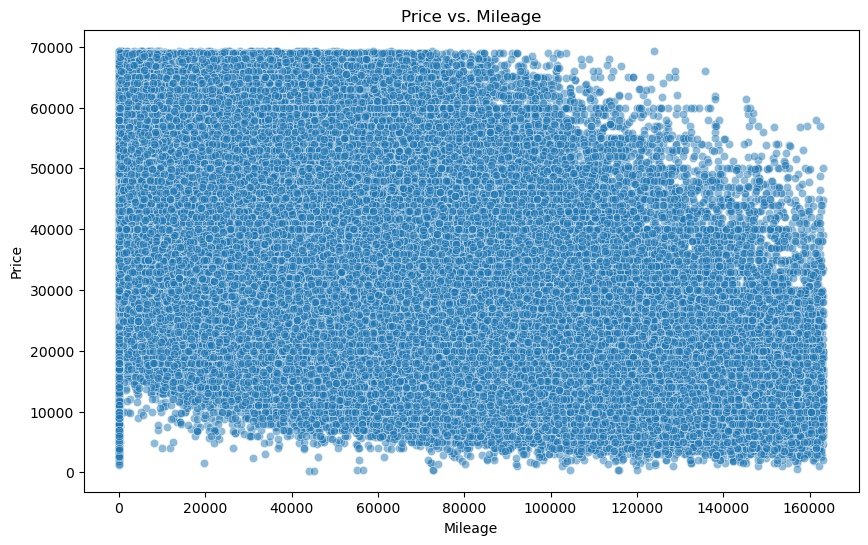

In [41]:
plt.figure(figsize=(10, 6)) 
sns.scatterplot(x='mileage', y='price', data=used_cars, alpha=0.5) 
plt.title('Price vs. Mileage') 
plt.xlabel('Mileage') 
plt.ylabel('Price') 
plt.show()


This scatterplot indicates a general trend of decreasing price with increased mileage, showing that mileage is also an important factor for the pricing of used vehicles. Like the previous scatterplot, there is an incredibly wide range of prices for each mileage level. This combined with the fact that some cars with higher mileage still appear to remain more expensive indicates that other factors (such as condition, manufacturer, and model) need to be combined in order to make more accurate predictions.

#### Distribution of Price vs Manufacturer

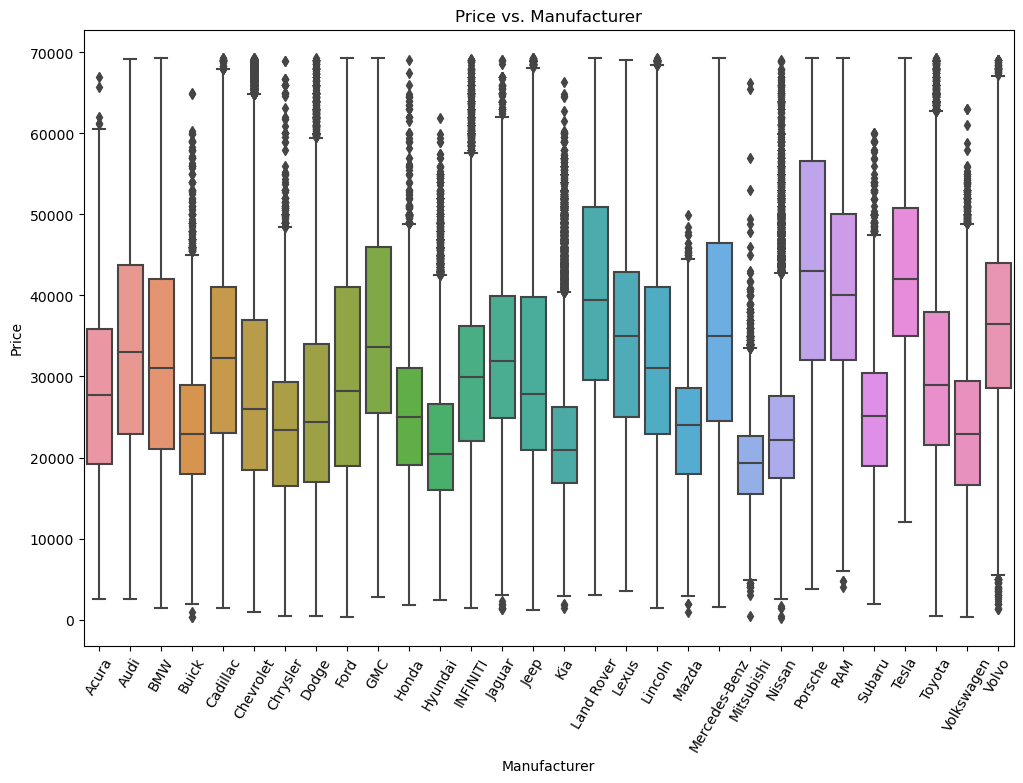

In [42]:
plt.figure(figsize=(12, 8)) 
sns.boxplot(x='manufacturer', y='price', data=used_cars) 
plt.title('Price vs. Manufacturer') 
plt.xlabel('Manufacturer') 
plt.ylabel('Price') 
plt.xticks(rotation=60) 
plt.show()


This boxplot illustrates the variation in used car prices across different auto manufacturers. More luxury manufacturers, notably Porsche, Land Rover, Tesla, and Mercedes-Benz, tend to have significantly higher median prices than more budget-friendly manufacturers like Kia, Nissan, and Hyundai. Luxury manufacturers also tend to have a larger interquartile range than more affordable manufacturers, indicating that pricing varies more and is less consistent than affordable options. Most brands also have outliers, showing that specific models likely have premium features and retain a very high value. 

#### Distribution of Car Price by Accidents

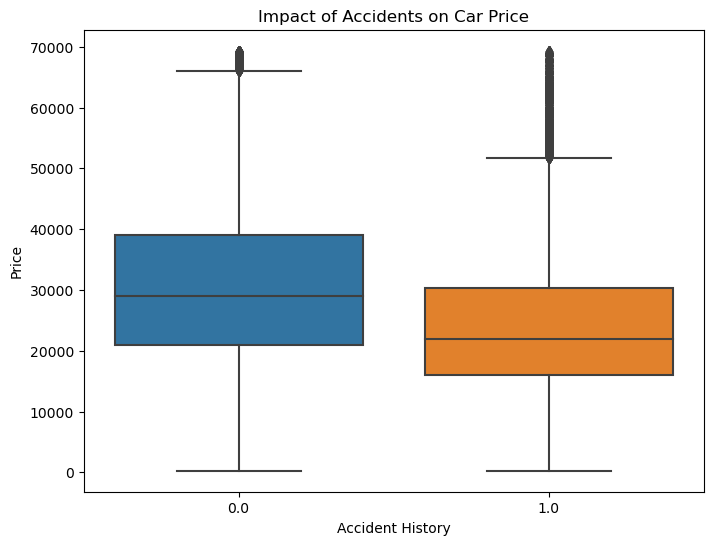

In [43]:
plt.figure(figsize=(8, 6)) 
sns.boxplot(x='accidents_or_damage', y='price', data=used_cars) 
plt.title('Impact of Accidents on Car Price') 
plt.xlabel('Accident History') 
plt.ylabel('Price') 
plt.show()

This boxplot shows the relationship between accident history and price, with those with no accident history represented by 0.0 and those with an accident history represented by 1.0. We can see that the median price for accident-free used vehicles is substantially higher than cars with an accident history, highlighting that an accident history significantly reduces a car’s resale value. Cars with an accident history have less variation in their price distribution, where accident-free cars have a wider price range. There are more high-priced outliers in the cars with an accident history, likely showing that luxury or well-repaired models may retain their value better. This suggests that repair quality may also influence vehicle pricing.

#### Distribution of Year vs Mileage - Multicollinearity Analysis

It is important to note that there may be multicollinearity in within our variables. We most suspect that year and mileage are not linearly independent, because it is natural to think that older cars have been driven for more miles than newer cars. In order to further examine this effect, we plot histograms of year vs mileage to see if there is indeed a relationship.

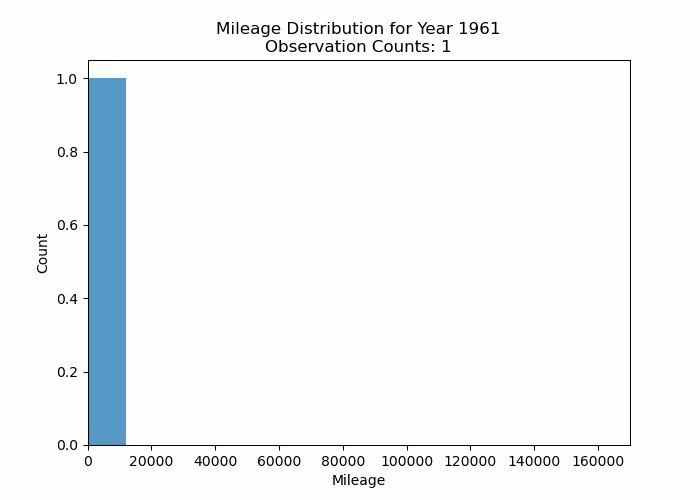

In [44]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(7, 5))

bins = np.linspace(0, 170000, 15)

unique_years = sorted(used_cars['year'].unique())

def update(year):
    ax.clear()
    x = used_cars[used_cars['year'] == year]['mileage']
    ax.hist(x, bins=bins, range=[0, 170000], alpha=0.75, density=False)
    ax.set_xlim(0, 170000)
    ax.set_xlabel('Mileage')
    ax.set_ylabel('Count')
    ax.set_title(f'Mileage Distribution for Year {year}\nObservation Counts: {len(x):,}')

ani = animation.FuncAnimation(
    fig, 
    update, 
    frames=unique_years, 
    repeat=False,
    interval=500
)

ani.save('mileage_distribution.gif', writer='pillow', fps=3)

plt.close()

display(Image(filename='mileage_distribution.gif'))

The image cannot be viewed from the GitHub notebook preview, but is named 'mileage_distribution.gif' and can be found in the same directory.

We observe from the animated histogram that mileage distributions vary significantly across different years, affirming the idea that year and mileage are interrelated. However, to determine whether this relationship actually results in multicollinearity, we calculate statistical measures.

In [45]:
# Pearson’s Correlation
used_cars[['year', 'mileage']].corr().applymap(lambda x: round(x, 2))

,year,mileage
year,1.00,-0.64
mileage,-0.64,1.00


In [46]:
# Variance Inflation Factor
X = used_cars[['year', 'mileage']]
X = X.dropna()
X = np.column_stack((np.ones(X.shape[0]), X))
vif = [round(variance_inflation_factor(X, i), 2) for i in range(1, X.shape[1])]
print(vif)

[1.69, 1.69]


We observe a Pearson’s Correlation (r) of -0.64, which indicates a negative relationship between year and mileage, which is consistent with intuition: older cars tend to have higher mileage, but the relationship isn't strictly linear. We also find a Variance Inflation Factor (VIF) of ≈1.69, which is low and thus suggests low multicollinearity, meaning mileage is not a linear function of year. Thus, we find that these two variables are correlated, but not multicollinear, and that including both variables in a regression model shouldn't cause instability.

This pattern also applies to our other variables. While it may be possible that there are more old cars from certain manufacturers, the data is still spread out to a degree where the multicollinearity is tolerable in our regression model:

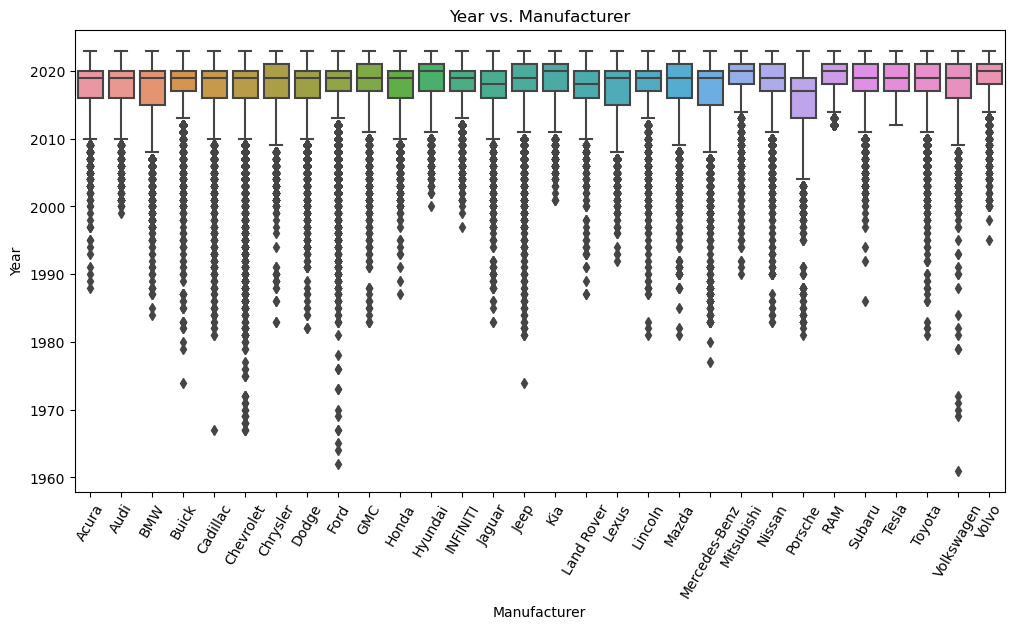

In [47]:
plt.figure(figsize=(12, 6)) 
sns.boxplot(x='manufacturer', y='year', data=used_cars) 
plt.title('Year vs. Manufacturer') 
plt.xlabel('Manufacturer') 
plt.ylabel('Year') 
plt.xticks(rotation=60) 
plt.show()

## Prediction Modeling

### Baseline Model

Onto predicting used car prices with the available data, we will first build a baseline multiple linear regression model, then experiment with other models as well. The column 'model' was dropped for this part, since one-hot encoding 12,187 unique values would take very long.

In [48]:
X = used_cars.drop(columns=['price', 'model'])
y = used_cars['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', ['year', 'mileage', 'accidents_or_damage', 'one_owner', 'personal_use_only']),
        ('cat', OneHotEncoder(drop='first', sparse_output =False), ['manufacturer', 'transmission', 'drivetrain', 'fuel_type'])
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Baseline Linear Regression Model Performance:')
print(f'Root Mean Squared Error: ${rmse:,.2f}')
print(f'R-squared Score: {r2:.4f}')

Baseline Linear Regression Model Performance:
Root Mean Squared Error: $7,841.06
R-squared Score: 0.6503


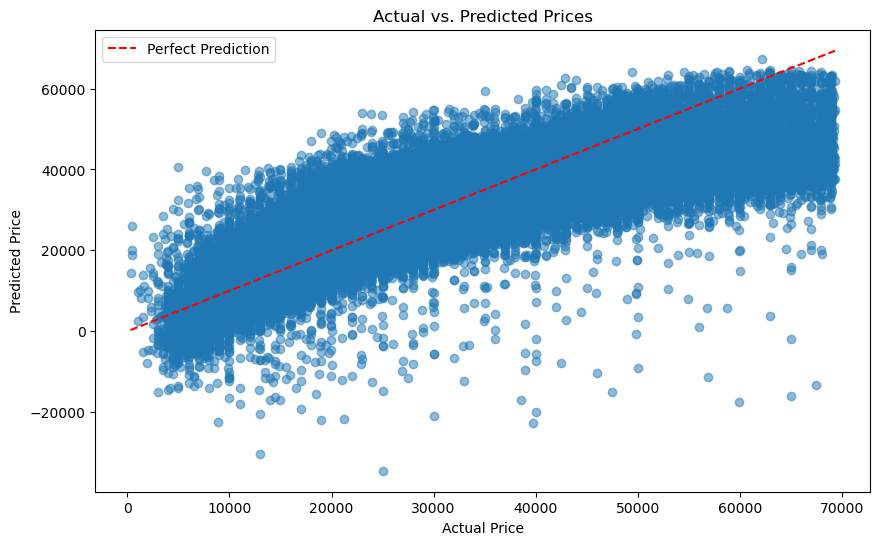

In [49]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted Prices')
plt.legend()
plt.show()

We see that the RMSE is $7,841.06, which doesn't seem too bad. Predictions demonstrate a rough understanding of the data, but that sometimes the predictions go to the negatives, which is something to be careful about when training other models. We can min-max standardize then train the same model, which would yield the same results but with more interpretable weights.

In [50]:
numeric_features = ['year', 'mileage', 'accidents_or_damage', 'one_owner', 'personal_use_only']
categorical_features = ['manufacturer', 'transmission', 'drivetrain', 'fuel_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('\nMin-max Standardized Linear Regression Model Performance:')
print(f'Root Mean Squared Error: ${rmse:,.2f}')
print(f'R-squared Score: {r2:.4f}')

numeric_feature_names = numeric_features
categorical_feature_names = []
for feature in categorical_features:
    unique_values = X[feature].unique()
    categorical_feature_names.extend([f'{feature}_{val}' for val in sorted(unique_values)[1:]])

feature_names = numeric_feature_names + categorical_feature_names

coefficients = pd.DataFrame(
    {'feature': feature_names,
     'coefficient': pipeline.named_steps['regressor'].coef_},
    columns=['feature', 'coefficient']
)

coefficients['abs_coef'] = abs(coefficients['coefficient'])
coefficients = coefficients.sort_values('abs_coef', ascending=False)

print('\nTop 10 Most Influential Features:')
print(coefficients[['feature', 'coefficient']].head(10))


Min-max Standardized Linear Regression Model Performance:
Root Mean Squared Error: $7,841.06
R-squared Score: 0.6503

Top 10 Most Influential Features:
                    feature   coefficient
0                      year  69046.450403
1                   mileage -19192.963384
38            fuel_type_gas -15856.424085
37       fuel_type_electric -14478.766352
39         fuel_type_hybrid -13983.246681
27     manufacturer_Porsche  13391.218782
25  manufacturer_Mitsubishi -10400.298154
29      manufacturer_Subaru  -8542.993325
35           drivetrain_FWD  -7990.046967
20  manufacturer_Land Rover   7029.172213


We see that year, mileage, and fuel type greatly influence the pricing predictions. After min-max standardizing, the feature scales are equal, so although the coefficients are large, they are comparable between each other.

### Model Experimentation

#### Random Forest Regressor

Now we try a random forest regressor, which still does not utilize the model feature because otherwise the training process would take a very long time as well. We use label encoding instead of one-hot encoding for this task because it is more memory efficient and because RandomForest would not misinterpret the labels as having ordinal relationships.

In [37]:
X = used_cars.drop(columns=['price', 'model'])
y = used_cars['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Random Forest Regression Model Performance:
Root Mean Squared Error: $7,423.72
R-squared Score: 0.6865

Top 10 Most Important Features:
               feature  importance
1                 year    0.349531
2              mileage    0.265179
4           drivetrain    0.155534
0         manufacturer    0.133110
5            fuel_type    0.062476
8    personal_use_only    0.011500
7            one_owner    0.010028
6  accidents_or_damage    0.009401
3         transmission    0.003241


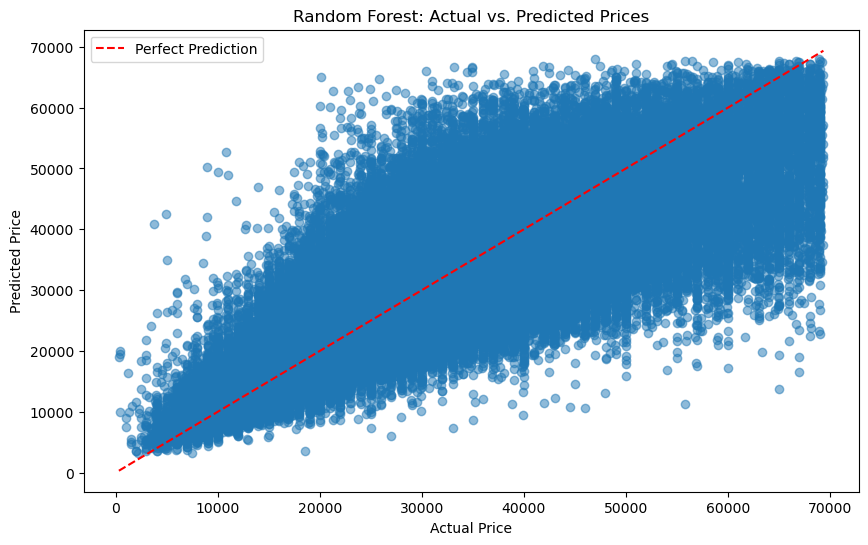

In [38]:
label_encoders = {}
categorical_features = ['manufacturer', 'transmission', 'drivetrain', 'fuel_type']

X_train_rf = X_train.copy()
X_test_rf = X_test.copy()

for feature in categorical_features:
    label_encoders[feature] = LabelEncoder()
    X_train_rf[feature] = label_encoders[feature].fit_transform(X_train_rf[feature])
    X_test_rf[feature] = label_encoders[feature].transform(X_test_rf[feature])

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train)

rf_pred = rf_model.predict(X_test_rf)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print('\nRandom Forest Regression Model Performance:')
print(f'Root Mean Squared Error: ${rf_rmse:,.2f}')
print(f'R-squared Score: {rf_r2:.4f}')

feature_importance = pd.DataFrame({
    'feature': X_train_rf.columns,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

print('\nTop 10 Most Important Features:')
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs. Predicted Prices')
plt.legend()
plt.show()

We see that our predictions no longer go into the negatives, but that the RMSE is still $7,423.72, which is only slightly better than the baseline model. We also again see that year and mileage are the two most important features in the tree model.

#### XGBoost Regressor

Now we try an XGBoost Regressor, where numerical features are min-max scaled and categorical features are one-hot encoded.

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros



XGBoost Regression Model Performance:
Root Mean Squared Error: $5,856.95
R-squared Score: 0.8049


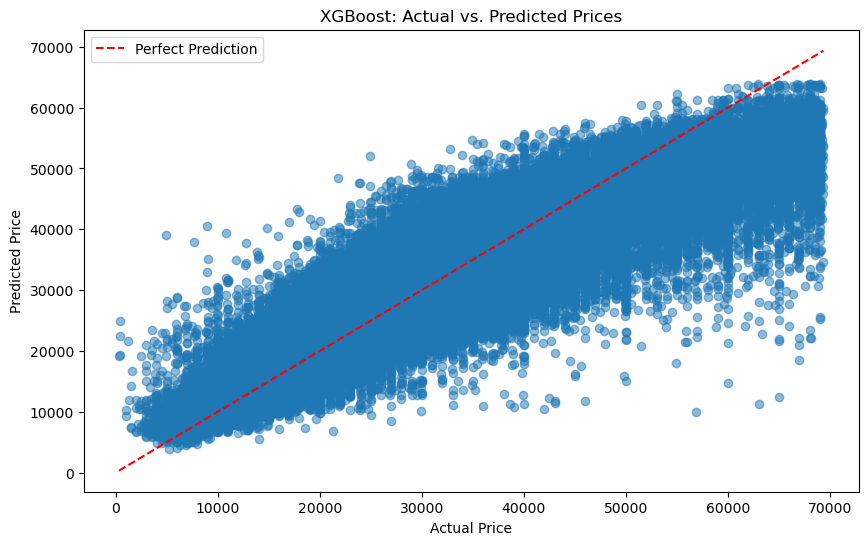

In [38]:
X = used_cars.drop(columns=['price'])
y = used_cars['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = ['year', 'mileage', 'accidents_or_damage', 'one_owner', 'personal_use_only']
categorical_features = ['manufacturer', 'model', 'transmission', 'drivetrain', 'fuel_type']

xgb_preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), 
         categorical_features)
    ])

X_train_xgb = xgb_preprocessor.fit_transform(X_train)
X_test_xgb = xgb_preprocessor.transform(X_test)

xgb_model = XGBRegressor(n_estimators=100, max_depth=5, random_state=42).fit(X_train_xgb, y_train)
xgb_pred = xgb_model.predict(X_test_xgb)

xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_pred)

print('\nXGBoost Regression Model Performance:')
print(f'Root Mean Squared Error: ${xgb_rmse:,.2f}')
print(f'R-squared Score: {xgb_r2:.4f}')

plt.figure(figsize=(10, 6))
plt.scatter(y_test, xgb_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('XGBoost: Actual vs. Predicted Prices')
plt.legend()
plt.show()

With XGBRegressor, the RMSE is now $5,856.95, which is much better than the baseline and RandomForestRegressor, yielding a 25.304% improvement from the baseline. It also continues to not predict negative values, which is a significant improvement from the baseline as well.

Below, we conduct a more thorough analysis of feature importance, using the builtin feature importances as well as shapley values. 

In [39]:
numeric_feature_names = numeric_features

categorical_feature_names = []
for feature in categorical_features:
    unique_vals = X_train[feature].unique()
    categorical_feature_names.extend([f'{feature}_{val}' for val in unique_vals[1:]])

all_feature_names = numeric_feature_names + categorical_feature_names

X_test_xgb_df = pd.DataFrame(X_test_xgb, columns=all_feature_names)

In [40]:
importance_dict = xgb_model.get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'feature': list(importance_dict.keys()),
    'importance': list(importance_dict.values())
}).sort_values('importance', ascending=False)
importance_df['feature'] = importance_df['feature'].map(lambda x: all_feature_names[int(x.replace('f',''))])

print('\nTop 10 Most Important Features (XGBoost):')
print(importance_df.head(10))


Top 10 Most Important Features (XGBoost):
                     feature  importance
1                    mileage       667.0
0                       year       584.0
341       drivetrain_AWD/4WD        97.0
344         fuel_type_diesel        79.0
342           drivetrain_RWD        62.0
2        accidents_or_damage        35.0
4          personal_use_only        17.0
19   manufacturer_Volkswagen        14.0
3                  one_owner        13.0
340      transmission_manual        11.0


We see that mileage and year have the greatest importance by far, which is consistent with observations from the previous models as well as intuition. These importance scores, however, don't indicate how feature values actually influence the predictions. Using shapley values, we are better able to visualize feature influence.

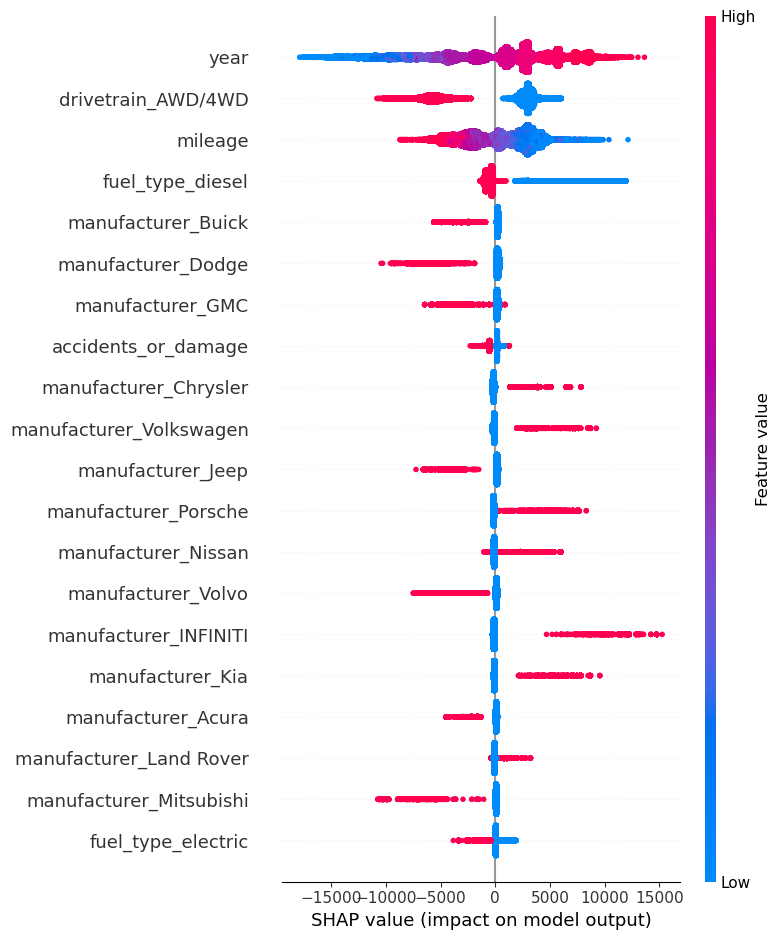

In [41]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_xgb_df)

shap.summary_plot(shap_values, X_test_xgb_df)

This shapley summary plot takes features and indicates how higher/lower feature values influence the prediction. SHAP values further from the center line at 0 indicate greater influence on price. The gradient indicates the feature value, whereas SHAP value indicates influence. For example, we see that for year, higher values (more recent years) correspond to positive influence (higher price). This remains consistent with previous observations, and provides interpretability of model choices.

We also see that for mileage, lower mileage corresponds to positive influence on price. The remaining features in the summary belong to one-hot encoded categorical variables, which explains the lack of gradient. Here, red points represent 1, which is True, while blue represents 0, False. For example, drivetrain_AWD/4WD being False would push the price prediction higher, which seems counterintuitive in that AWD/4WD cars are usually more expensive than their 2WD counterparts. We then take further observations to determine if the model ultimately predicts AWD/4WD cars as generally more expensive, since the model may simply leverage other features to reach similar conclusions.

In [42]:
mazda = X_test[(X_test['manufacturer'] == 'Mazda') & (X_test['model'] == 'CX-5 Touring')]
mazda_y = y_test.loc[mazda.index]
mazda.head()

,manufacturer,model,year,mileage,transmission,drivetrain,fuel_type,accidents_or_damage,one_owner,personal_use_only
509768,Mazda,CX-5 Touring,2014,84382.0,automatic,AWD/4WD,gas,1.0,1.0,1.0
508857,Mazda,CX-5 Touring,2020,27413.0,automatic,AWD/4WD,gas,0.0,1.0,0.0
509710,Mazda,CX-5 Touring,2020,55495.0,automatic,AWD/4WD,gas,0.0,1.0,0.0
506390,Mazda,CX-5 Touring,2021,48992.0,automatic,FWD,gas,1.0,1.0,0.0
508647,Mazda,CX-5 Touring,2020,23651.0,automatic,FWD,gas,0.0,1.0,1.0


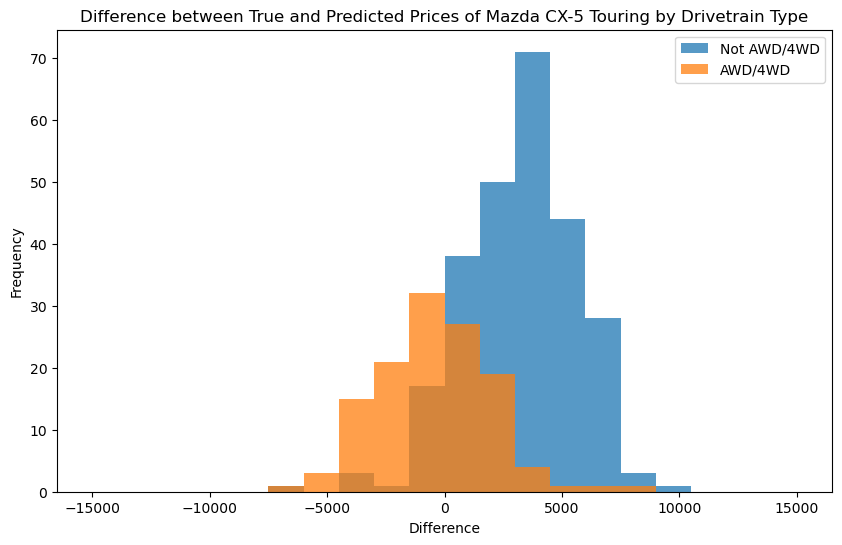

In [43]:
mazda_xgb = xgb_preprocessor.transform(mazda)
mazda_xgb = pd.DataFrame(mazda_xgb, columns=all_feature_names)
y_pred_mazda = xgb_model.predict(mazda_xgb)

comparison_df = pd.DataFrame({
    'True Price': mazda_y,
    'Predicted Price': y_pred_mazda,
    'AWD/4WD': mazda_xgb['drivetrain_AWD/4WD'].to_numpy()
})

plt.figure(figsize=(10,6))

labels = ['Not AWD/4WD', 'AWD/4WD']
colors = ['#1f77b4', '#ff7f0e']

for i in [0,1]:
    temp_df = comparison_df[comparison_df['AWD/4WD'] == i]
    diff = temp_df['Predicted Price'] - temp_df['True Price']
    plt.hist(diff, range=[-15000, 15000], bins=20, 
            color=colors[i], alpha=0.75, label=labels[i])

plt.title('Difference between True and Predicted Prices of Mazda CX-5 Touring by Drivetrain Type')
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.legend()
plt.show()


To observe drivetrain we plot the difference between true and predicted prices of a certain car model, Mazda CX-5 Touring. This model has AWD/4WD and FWD options, so plotting the error can provide insights upon the model's emphasis on drivetrain. We see that the orange histogram, representing AWD/4WD, is roughly normal and centered at 0. The blue histogram for non-AWD/4WD is also roughly normal, but instead centered approximately at 4,000. This suggests that the model may place a false emphasis on non-AWD/4WD drivetrains (and potentially features related to it) which results in these predictions that are systematically higher than truth values. This suggests that our model does not reflect conventional knowledge like humans do with respect to drivetrain, and that it more so just takes "optimal" feature combinations to produce its predictions.

# Ethics & Privacy

- Data Privacy & Anonymization
   - If using real-world datasets from sources like Craigslist, Kelley Blue Book, etc., we must ensure that personally identifiable information is not included.
   - Seller details, phone numbers, or exact location data should not be collected/stored.
   - We will only use publicly available or anonymized data for our analysis.
- Bias & Fairness
   - Used car pricing can be influenced by factors such as location, brand perception, and economic disparities.
   - Our model must avoid reinforcing biases, like undervaluing cars in certain areas/neighborhoods or unfairly weighing brand reputation over real condition.
- Misuse of Predictions
   - While our goal is to help consumers make informed decisions, there is a risk that dealerships or individuals could exploit our model to manipulate pricing.
   - We will provide transparency in our methodology and highlight limitations in our model to prevent misuse.
- Ethical Data Sourcing
   - If scraping data from websites, we must comply with terms of service and fair use policies.
   - If using proprietary datasets, we will ensure we have proper permissions or use open-source alternatives.


When analyzing used car pricing and building a predictive model, we took care at each step to address ethical and privacy concerns. We sourced our dataset from Kaggle, meaning that our data was already publicly available from cars.com and pre-processed. In order to uphold privacy standards, we also verified that no personally identifiable information was present in the data. We also removed the seller name category to ensure that we did not accidentally reveal any private data.  

Even though our dataset was publicly available and anonymous, we acknowledged that biases would still be present within the data. Factors such as location, brand perception, and economic disparities all have the potential to influence used car pricing. This dataset does not include such data, but we acknowledge these potential biases in our findings and do not generalize our findings past the United States. 

Finally in the publication of our result, we would like to acknowledge that while we intend for this model to be a transparent tool to analyze used car pricing that benefits the consumer, there is the potential that individual sellers or dealerships could exploit this to manipulate pricing. To avoid this, we were transparent about our methodology throughout this project, and we highlight any possible limitations to prevent misuse.

# Discussion and Conclusion

For this project, we were aiming to find which factors were most important in determining a used car’s value. To achieve this, we used an online dataset of used cars and analyzed them through several regression models. For each model, we judged accuracy through the overall root mean squared error, and took the coefficients of each variable, showing which factors were most important in the pricing of a car. When looking to find the most important factors in predicting the price of used cars, we found that mileage and year were the two most important factors in determining a car’s value. This data ultimately did not support our hypothesis, as the regression coefficients of mileage and year were much higher than the coefficient of the accident variable. 

Before building our predictive models, we performed data cleaning and exploratory data analysis to make sure that our data would be easy and accurate to work with and to more deeply understand the patterns in our data. We first dropped nine columns from our dataset that had included many null values, were too inconsistent to work with, or that didn’t offer much useful insight. We then addressed missing values and inconsistencies in our remaining columns, making sure that categorical variables such as transmission, fuel type, and drive train were collapsed into their main categories. We then removed outliers and performed exploratory data analysis on our cleaned dataset. 

During EDA, we created visualizations to understand the relationships between selling price and other variables in our dataset. We analyzed selling price’s relationships with year, mileage, manufacturer, and accident history. Mileage and year showed a very clear inverse relationship with price, highlighting that older cars with higher mileage tended to have lower selling prices. This strong correlation was later confirmed by our regression models. We also found that price varied more within more luxury manufacturers, whilst most affordable brands were priced more consistently.   

To predict used car prices, we compared three different regression models: a baseline linear regression model, a Random Forest Regressor, and an XGBoost Regressor. We compared these more complex models to our baseline to determine if they offered any significant improvements.

- Baseline Linear Regression: Training this model allowed us to start to understand the relationships between features and price. With a root mean squared error of $7,841.06 and an R-squared score of 0.6503, there was a lot of room for improvement.

- Random Forest Regressor: This model showed a lot of improvement from our baseline, with predicted values no longer going into the negatives, a root mean squared error of $7,423.72, and an R-squared score of 0.6865. We also conducted feature importance analysis in this stage, showing that year, mileage, and drive train were the three most important factors in predicting price. 

- XGBoost Regressor: This model showed the best overall predictive performance, further reducing the root mean squared error to $5,856.95 and the R-squared score to 0.8049. Feature importance rankings confirmed that mileage, year, and drive train remained the most important factors in predicting selling price. 

From here, we then conducted a more thorough analysis of feature importance using builtin feature importances from our XGBoost model and shapley values. Shapley values allowed us to better visualize feature importance by indicating how higher and lower feature values influence the prediction. We confirmed that for year, more recent years corresponded to a higher price. We also confirmed that lower mileage corresponded to a positive influence on price. 

While our final model ultimately achieved a strong predictive performance with a high R-squared value, it does still have some limitations in its real world applications. For one, our model does not account for external economic factors and market trends, which can all influence used car pricing. Our dataset also did not specify the severity of the accidents in a vehicle’s history, which also could play a role in pricing. The model also doesn't necessarily follow common knowledge. For instance, the feature analysis indicated that our model would assign lower pricing to AWD/4WD cars. This is somewhat counterintuitive, because in reality, AWD/4WD cars are usually more expensive than 2WD cars. We recognize through further exploration that the model may systematically over-predict the prices of non-AWD/4WD cars, which highlights how our model does not reflect domain knowledge, at least in terms of drivetrain. Finally, our model does not take into consideration brand perception, which may result in a bias within our model. 

Our analysis ultimately revealed that mileage and year are the most important factors when determining a used car’s selling price, contradicting our initial hypothesis that accident history would be the most important. Our analysis and model can aid both buyers and sellers in making informed decisions about car value.

Unlike past projects where manufacturer and optional feature packages play a larger role, our project emphasized more fundamental depreciation factors, such as mileage and year, in an attempt to be as unbiased as possible. This consideration provides a way for buyers to look at used cars’ values in a more unbiased way and make more informed decisions on whether or not a vehicle is priced fairly. In addition to helping consumers make more educated choices, our project also provides a useful tool for car dealerships and online marketplaces to help set competitive and fair prices. Predictive models like ours can also be used by insurance companies when setting prices for used vehicles. 




# Team Contributions

Monica: finding dataset; data cleaning; a little EDA; model training; conclusion; video

Maria: Project Proposal ethics & privacy, team expectations, timeline; background research, data visualizations, video

Diego: Question; hypothesis; helped in background research; timeline; a little EDA; team expectations; video

Maya: background research; ethics & privacy; abstract; conclusion; EDA; video